Module: WM9B7 - Artificial Intelligence and Deep Learning
**Student:** Ioannis Konstantinou | **Student ID:** u5750302<br>
**Assessment:** Individual Assessment - Credit Card Fraud Detection<br>
**Module Leader:** Dr Leonardo Alves Dias<br>
**Submission Date:** 27 April 2025

# Credit Card Fraud Detection: A Deep Learning Approach

---

## README and Setup Guide

### Problem Description
Credit card fraud is a significant financial crime that causes billions of dollars in
losses each year. This notebook develops and compares multiple machine learning and
deep learning approaches to detect fraudulent transactions from anonymised credit card
data. The core challenge is severe class imbalance, where fraud cases represent only
approximately 0.17% of all transactions.

### Dataset Description
**Source:** [Kaggle - Credit Card Fraud Detection (mlg-ulb)](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)
**File:** creditcard.csv
- 284,807 transactions with 492 fraud cases (0.17%)
- Features V1 to V28: PCA-transformed anonymised features
- Time: seconds elapsed since the first transaction
- Amount: transaction amount in EUR
- Class: target variable (1 = Fraud, 0 = Legitimate)
- Licence: CC0 Public Domain

---

### How to Run
1. Open this notebook in Google Collab, or Azure.
2. Press Run All
3. The setup cell installs all required libraries automatically and downloads
   the dataset directly from Kaggle without requiring an account or token

No manual configuration is needed. The dataset download is handled programmatically
on every run and cached locally after the first execution.

---

### Required Libraries
All libraries are installed automatically with pinned versions by the first cell:

| Library | Version | Purpose |
|---|---|---|
| pandas | 2.2.2 | Data manipulation |
| numpy | 1.26.4 | Numerical operations |
| matplotlib | 3.9.0 | Visualisation |
| seaborn | 0.13.2 | Statistical plots |
| scikit-learn | 1.5.0 | Traditional ML models, preprocessing, evaluation |
| tensorflow | 2.16.1 | Deep learning models (ANN, LSTM, Autoencoder) |
| xgboost | 2.0.3 | Gradient boosting |
| imbalanced-learn | 0.12.3 | SMOTE oversampling |
| kagglehub | 0.3.4 | Automatic dataset download |

---

### Academic Note
This notebook critically compares traditional machine learning, deep learning, and
unsupervised anomaly detection methods. Deep learning is not assumed to outperform
classical methods, particularly on tabular data. Design decisions, trade-offs, and
limitations are discussed throughout.


---
## Section 1: Kaggle Configuration

In [2]:
# CELL: Environment setup
# This cell installs all required libraries and downloads the dataset.
# It is designed to be environment-agnostic (VS Code, Colab, Jupyter).
import os, shutil, glob, importlib, subprocess, sys

# Preferred versions for reproducibility
PACKAGES = [
    'numpy==1.26.4', 'pandas==2.2.2', 'matplotlib==3.9.0',
    'seaborn==0.13.2', 'scikit-learn==1.5.0', 'tensorflow==2.16.1',
    'xgboost==2.0.3', 'imbalanced-learn==0.12.3', 'kagglehub==0.3.4'
]

print('Checking environment and dependencies...')

for pkg in PACKAGES:
    name = pkg.split('==')[0]
    mod  = name.replace('-', '_')
    try:
        importlib.import_module(mod)
    except Exception:
        try:
            print(f'Installing {pkg}...')
            subprocess.check_call([sys.executable, '-m', 'pip', 'install',
                                   pkg, '-q', '--disable-pip-version-check'],
                                  stdout=subprocess.DEVNULL)
        except subprocess.CalledProcessError:
            print(f'  {pkg} unavailable for this Python. Installing latest {name}...')
            subprocess.check_call([sys.executable, '-m', 'pip', 'install',
                                   name, '-q', '--disable-pip-version-check'],
                                  stdout=subprocess.DEVNULL)

# Downloading the dataset directly from Kaggle
# After the first run the dataset is cached locally so subsequent runs are faster
import kagglehub
path = kagglehub.dataset_download('mlg-ulb/creditcardfraud')
csv  = glob.glob(os.path.join(path, '**', 'creditcard.csv'), recursive=True)[0]

DATASET_DIR  = './dataset'
os.makedirs(DATASET_DIR, exist_ok=True)
DATASET_FILE = os.path.join(DATASET_DIR, 'creditcard.csv')
if not os.path.exists(DATASET_FILE):
    shutil.copy(csv, DATASET_FILE)

print(f'Dataset ready: {DATASET_FILE}')
print(f'Size: {os.path.getsize(DATASET_FILE)/1e6:.1f} MB')


Checking environment and dependencies...
Installing scikit-learn==1.5.0...
Installing imbalanced-learn==0.12.3...
Dataset ready: ./dataset/creditcard.csv
Size: 150.8 MB


2026-04-26 23:38:21.800685: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-26 23:38:21.800729: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-26 23:38:21.802045: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-26 23:38:21.809477: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-26 23:38:22.645342: W tensorflow/compiler/tf2

---
## Section 2: Imports and Configuration

In [3]:
import time as _t
_s = _t.time()
print('Imports starting...')

# Standard libraries
import warnings
import numpy as np
import pandas as pd

# Visualisations
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Scikit-learn preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold

# Scikit-learn models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.svm import SVC

# Scikit-learn evaluation
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score,
    f1_score, precision_score, recall_score
)

# XGBoost
from xgboost import XGBClassifier

# Imbalanced learning
from imblearn.over_sampling import SMOTE

# TensorFlow and Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import regularizers



# Suppress noise
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# Fix random seeds for full reproducibility across every run
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# Personal colour theme
# Colors: https://coolors.co/ff595e-ff924c-ffca3a-c5ca30-8ac926-36949d-1982c4-4267ac-565aa0-6a4c93
C_LEGIT   = '#1982c4'   # Steel Blue - legitimate transactions
C_FRAUD   = '#ff595e'   # Vibrant Coral - fraud
C_ACCENT  = '#8ac926'   # Yellow Green - correct / highlights
C_WARN    = '#ff924c'   # Tangerine Dream - thresholds / warnings
C_DARK    = '#6a4c93'   # Dusty Grape - text / outlines

# Named palette for plots split by class
PALETTE = {'Legitimate': C_LEGIT, 'Fraud': C_FRAUD}

# Colour list for model comparison charts, one colour per model
COLORS  = [C_LEGIT, C_FRAUD, C_ACCENT, C_WARN, '#1982c4',
           '#ff595e', '#8ac926', '#ff924c']

# Applying theme globally so every chart in the notebook uses these settings
plt.rcParams.update({
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : '#F8F9FA',
    'axes.edgecolor'    : '#CCCCCC',
    'axes.labelcolor'   : C_DARK,
    'axes.titlesize'    : 13,
    'axes.titleweight'  : 'bold',
    'axes.titlecolor'   : C_DARK,
    'axes.grid'         : True,
    'grid.alpha'        : 0.3,
    'grid.color'        : '#CCCCCC',
    'xtick.color'       : C_DARK,
    'ytick.color'       : C_DARK,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'legend.framealpha' : 0.9,
    'legend.edgecolor'  : '#CCCCCC',
    'font.size'         : 11,
})

sns.set_theme(style='whitegrid', palette=COLORS, font_scale=1.1)

print(f'TensorFlow version : {tf.__version__}')
print(f' Numpy version       : {np.__version__}')
print(f'Pandas version      : {pd.__version__}')
print(f' Random seed set to  : {RANDOM_SEED}')

print(f'Imports done in {(_t.time()-_s):.1f}s')

# Start total runtime clock
# The final cell will use this to print how long the whole notebook took
import time as _time
_NOTEBOOK_START = _time.time()

Imports starting...
TensorFlow version : 2.15.0
 Numpy version       : 1.23.5
Pandas version      : 1.5.3
 Random seed set to  : 42
Imports done in 0.1s


In [4]:
import time as _t
_NOTEBOOK_START = _t.time()
print(' Notebook started - total runtime shown at the end')


 Notebook started - total runtime shown at the end


---
## Section 3: Exploratory Data Analysis (EDA)

Before building any model, it is important to understand the data properly. EDA shapes every decision that follows, from preprocessing choices to model selection and evaluation. The most important finding at this stage is the extreme class imbalance, which drives the entire approach taken in this project.

In [5]:
print(DATASET_FILE)

./dataset/creditcard.csv


In [6]:
df = pd.read_csv(DATASET_FILE)

print('DATASET OVERVIEW')
print(f'  Shape            : {df.shape[0]:,} rows  {df.shape[1]} columns')
print(f'  Memory usage     : {df.memory_usage(deep=True).sum() / 1e6:.2f} MB')
print(f'  Missing values   : {df.isnull().sum().sum()}')
print(f'  Duplicate rows   : {df.duplicated().sum()}')

print("\n")
print('=' * 60)

# Class distribution
print('CLASS DISTRIBUTION')
class_counts = df['Class'].value_counts()
fraud_pct = class_counts[1] / len(df) * 100
print(f"Legitimate       : {class_counts[0]:,} ({100-fraud_pct:.4f}%)")
print(f"Fraud            : {class_counts[1]:,} ({fraud_pct:.4f}%)")
print(f"Imbalance Ratio  : {class_counts[0]//class_counts[1]}:1")

print(f'Dataset loaded in {(_t.time()-_s):.1f}s')

DATASET OVERVIEW
  Shape            : 284,807 rows  31 columns
  Memory usage     : 70.63 MB
  Missing values   : 0
  Duplicate rows   : 1081


CLASS DISTRIBUTION
Legitimate       : 284,315 (99.8273%)
Fraud            : 492 (0.1727%)
Imbalance Ratio  : 577:1
Dataset loaded in 2.8s


In [7]:
print(f"Highly imbalanced dataset  : {class_counts[0]//class_counts[1]}:1")

Highly imbalanced dataset  : 577:1


In [8]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [9]:
print('Data Types')
print(df.dtypes)
print()
print('Descriptive Statistics (Amount and Time)')
df[['Time', 'Amount', 'Class']].describe().round(4)

Data Types
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

Descriptive Statistics (Amount and Time)


,Time,Amount,Class
count,284807.0000,284807.0000,284807.0000
mean,94813.8596,88.3496,0.0017
std,47488.1460,250.1201,0.0415
min,0.0000,0.0000,0.0000
25%,54201.5000,5.6000,0.0000
50%,84692.0000,22.0000,0.0000
75%,139320.5000,77.1650,0.0000
max,172792.0000,25691.1600,1.0000


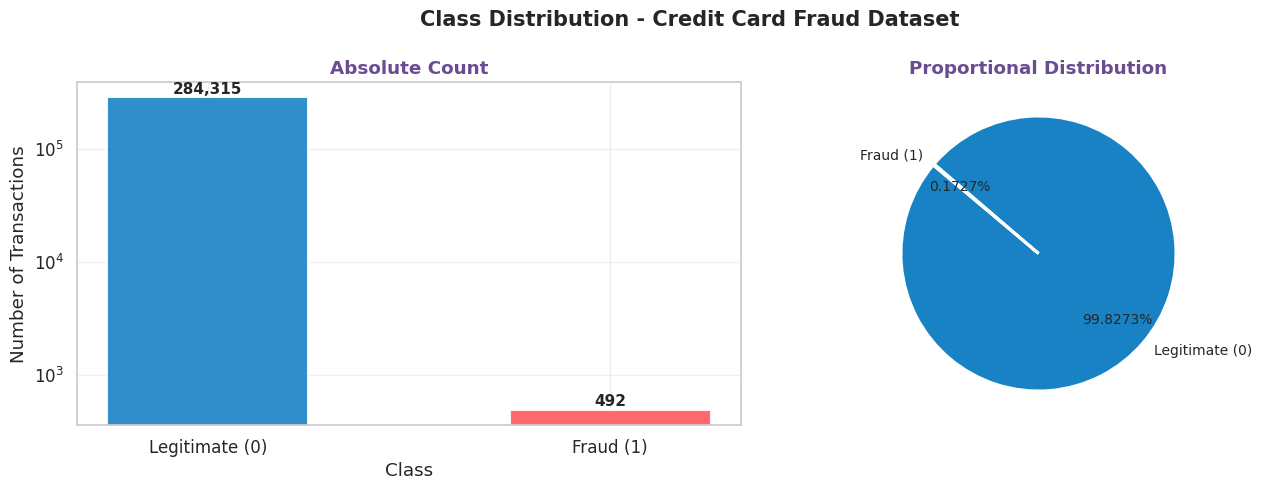

In [10]:
# Class imbalance visualisation
# The imbalance is so severe that standard accuracy becomes meaningless as a metric.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Class Distribution - Credit Card Fraud Dataset', fontsize=15, fontweight='bold')

#  Left: Count plot
labels = ['Legitimate (0)', 'Fraud (1)']
counts = [class_counts[0], class_counts[1]]
bars = axes[0].bar(labels, counts, color=[C_LEGIT, C_FRAUD], edgecolor='white',
                   linewidth=1.5, width=0.5, alpha=0.9)
for bar, count in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
                 f'{count:,}', ha='center', va='bottom', fontweight='bold', fontsize=11)
axes[0].set_title('Absolute Count', fontweight='bold')
axes[0].set_ylabel('Number of Transactions')
axes[0].set_yscale('log')
axes[0].set_xlabel('Class')

#  Right: Pie chart
wedge_props = dict(edgecolor='white', linewidth=2)
axes[1].pie(
    counts, labels=labels, autopct='%1.4f%%',
    colors=[C_LEGIT, C_FRAUD], startangle=140,
    wedgeprops=wedge_props, pctdistance=0.75,
    textprops={'fontsize': 10}
)
axes[1].set_title('Proportional Distribution', fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

Extreme imbalance confirmed. A model that predicts every transaction as legitimate
would achieve 99.83% accuracy while detecting zero fraud. For this reason, Precision,
Recall, F1-Score and ROC-AUC are used as the primary evaluation metrics throughout
this notebook.

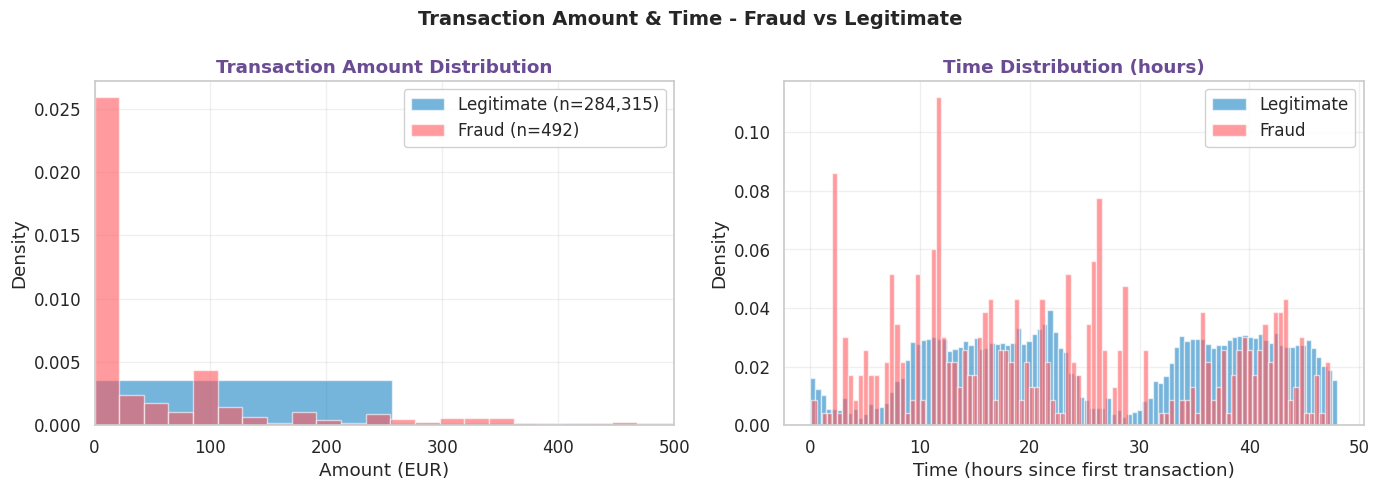

In [11]:
# Amount and time distributions split by class
# Amount is clipped at 500 EUR to make the chart readable since most transactions are small
# Time is converted from seconds to hours for easier interpretation

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Transaction Amount & Time - Fraud vs Legitimate', fontsize=14, fontweight='bold')

for cls, color, label in [(0, C_LEGIT, 'Legitimate'), (1, C_FRAUD, 'Fraud')]:
    subset = df[df['Class'] == cls]
    axes[0].hist(subset['Amount'], bins=100, alpha=0.6, color=color,
                 label=f'{label} (n={len(subset):,})', density=True)
    axes[1].hist(subset['Time'] / 3600, bins=100, alpha=0.6, color=color,
                 label=f'{label}', density=True)

axes[0].set_title('Transaction Amount Distribution')
axes[0].set_xlabel('Amount (EUR)')
axes[0].set_ylabel('Density')
axes[0].set_xlim(0, 500)
axes[0].legend()

axes[1].set_title('Time Distribution (hours)')
axes[1].set_xlabel('Time (hours since first transaction)')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.savefig('amount_time_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

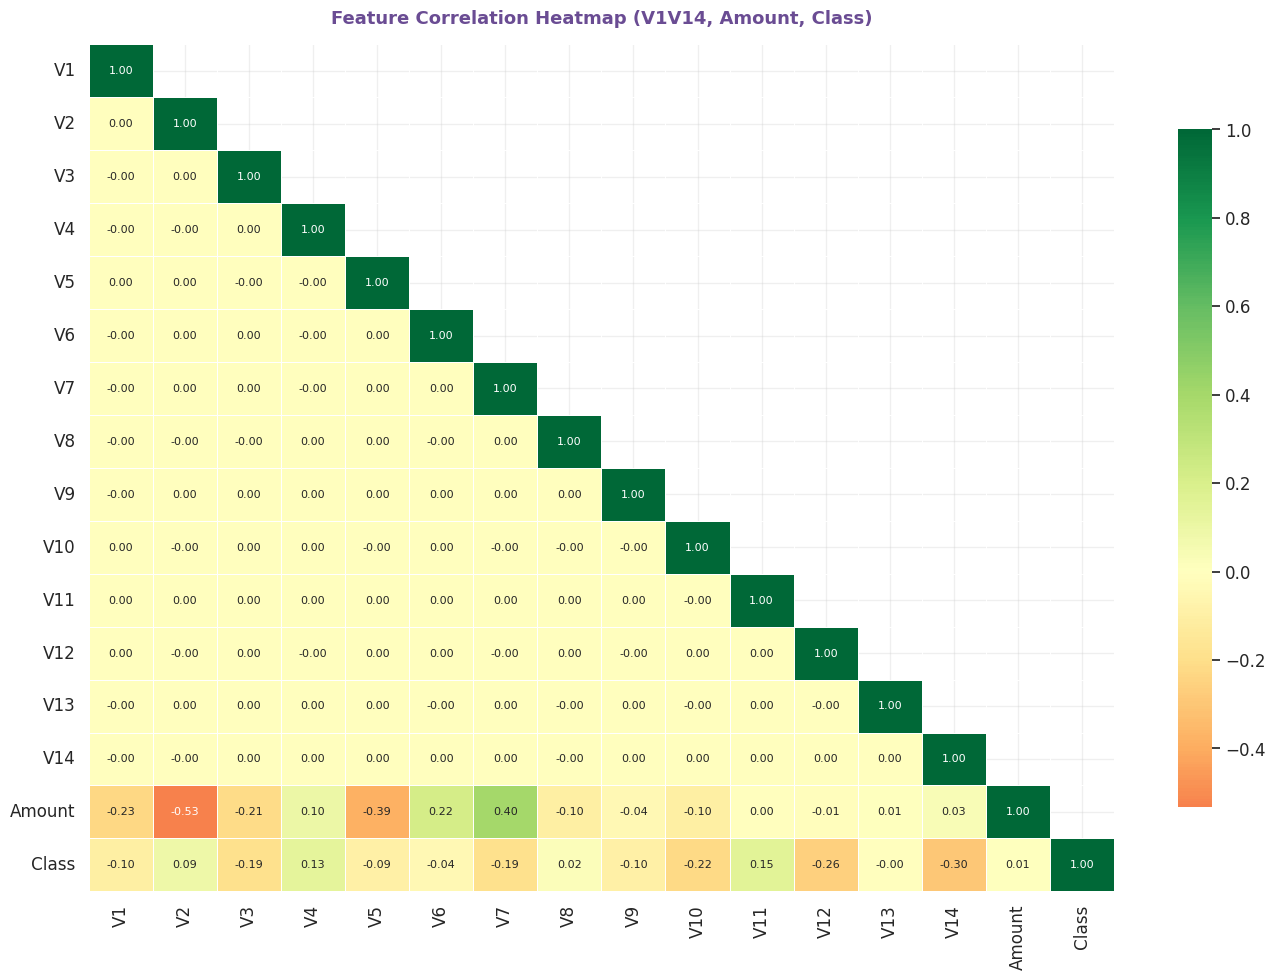

In [12]:
# Correlation Heatmap (Fraud subset)
# Sample for visualisation (full heatmap would be too dense to read)
corr_features = ['V1','V2','V3','V4','V5','V6','V7','V8','V9','V10',
                 'V11','V12','V13','V14','Amount','Class']

fig, ax = plt.subplots(figsize=(14, 10))
corr_matrix = df[corr_features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(
    corr_matrix, mask=mask, ax=ax,
    cmap='RdYlGn', center=0, annot=True, fmt='.2f',
    annot_kws={'size': 8}, linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Feature Correlation Heatmap (V1V14, Amount, Class)',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

The V features are PCA-transformed, so their original meaning is not recoverable.
Features with a high absolute correlation with Class are the most useful for
distinguishing fraud from legitimate transactions.

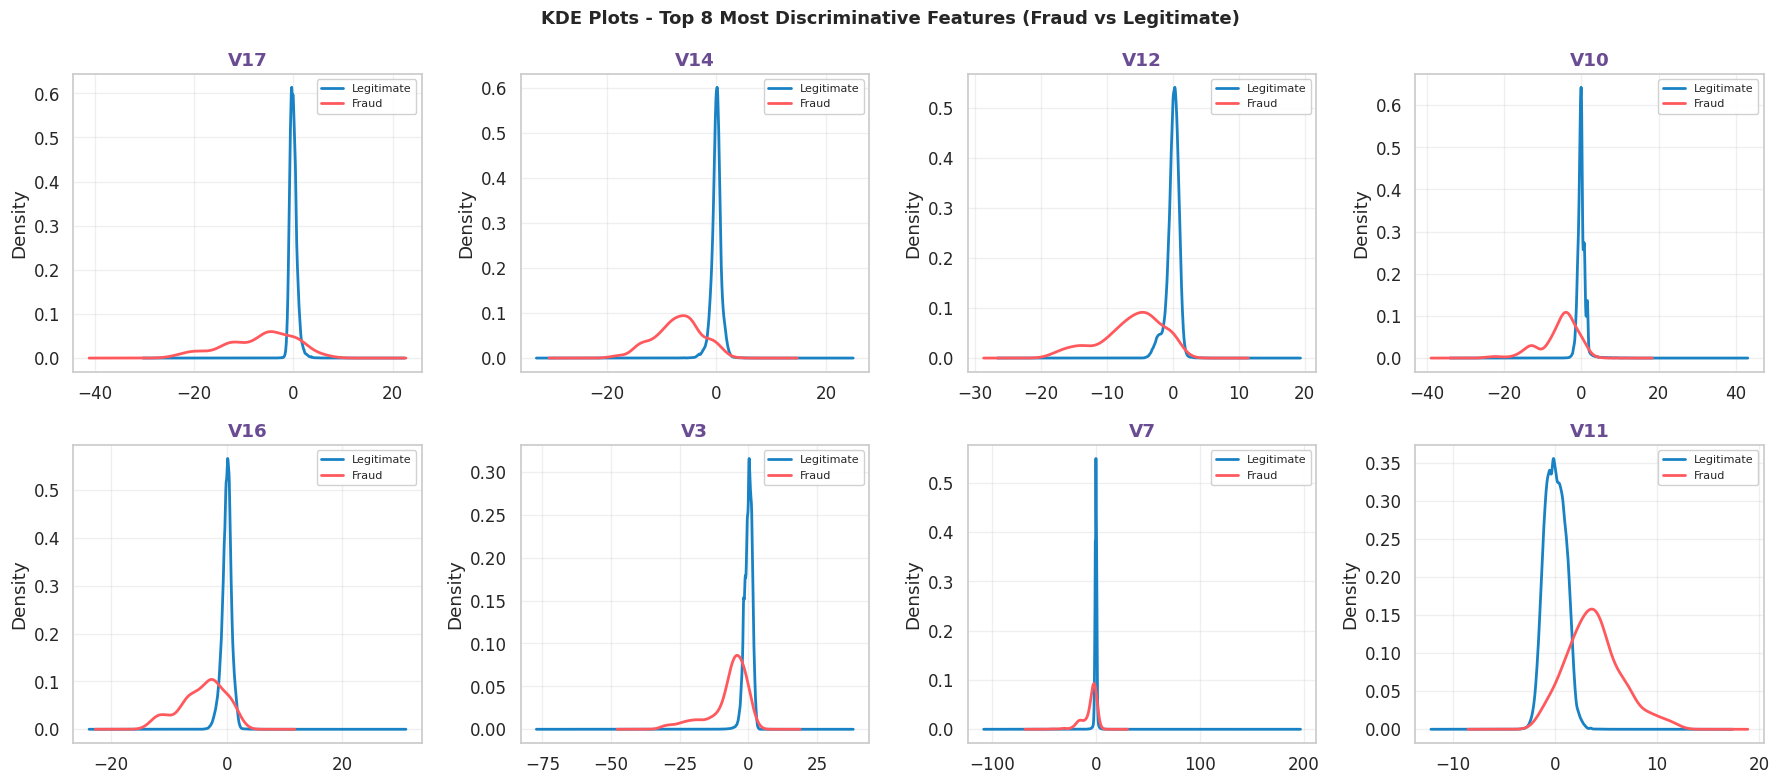

In [13]:
# KDE plots for the top 8 features most correlated with the Class label
# These are the features that differ most between fraud and legitimate transactions and are therefore the most useful for detection

top_features = df.corr()['Class'].abs().sort_values(ascending=False) \
                 .drop('Class').head(8).index.tolist()

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('KDE Plots - Top 8 Most Discriminative Features (Fraud vs Legitimate)',
             fontsize=13, fontweight='bold')

for ax, feature in zip(axes.flatten(), top_features):
    for cls, color, label in [(0, C_LEGIT, 'Legitimate'), (1, C_FRAUD, 'Fraud')]:
        subset = df[df['Class'] == cls][feature]
        subset.plot.kde(ax=ax, color=color, label=label, linewidth=2)
    ax.set_title(f'{feature}', fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_xlabel('')

plt.tight_layout()
plt.savefig('kde_features.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 4: Data Preprocessing

### Design Choices

1. **Feature Scaling**: Amount and Time are on very different scales compared to the
PCA features V1 to V28. StandardScaler is applied to normalise them to zero mean and
unit variance. Although V1 to V28 are already PCA-transformed, scaling all features
uniformly ensures consistency for distance-based models and neural networks.

2. **Stratified Split**: An 80/20 train-test split is used with stratification to
preserve the original class imbalance ratio in both sets. Without stratification,
the already rare fraud cases could be unevenly distributed, leading to biased results.

3. **SMOTE applied to training data only**: Applying SMOTE to the validation or test
set would constitute data leakage, as synthetic samples would carry information from
the training distribution into evaluation. All oversampling is applied strictly after
the split and only to the training fold.

In [14]:
# Separate features and target
X = df.drop(columns=['Class'])
y = df['Class']

feature_names = X.columns.tolist()
print(f'Features shape : {X.shape}')
print(f'Target shape   : {y.shape}')

# Stratified 80/20 split to preserve the fraud ratio in both sets
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

# Split the 20% test portion in half to create a validation set
# This gives 80% train, 10% validation, 10% test
X_val_raw, X_test_raw, y_val, y_test = train_test_split(
    X_test_raw, y_test,
    test_size=0.5,
    random_state=RANDOM_SEED,
    stratify=y_test
)


print(f'\nTrain size     : {len(X_train_raw):,} | Fraud: {y_train.sum():,}')
print(f'Validation size: {len(X_val_raw):,} | Fraud: {y_val.sum():,}')
print(f'Test size      : {len(X_test_raw):,}  | Fraud: {y_test.sum():,}')

Features shape : (284807, 30)
Target shape   : (284807,)

Train size     : 227,845 | Fraud: 394
Validation size: 28,481 | Fraud: 49
Test size      : 28,481  | Fraud: 49


In [15]:
# Standardisation + Before After Comparison

# Fit scaler ONLY on training data to avoid data leakage please
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_val_scaled   = scaler.transform(X_val_raw)          # no leakage
X_test_scaled  = scaler.transform(X_test_raw)

# Convert back to dataframe for easier handling
X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_names)
X_val_scaled   = pd.DataFrame(X_val_scaled,   columns=feature_names)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=feature_names)

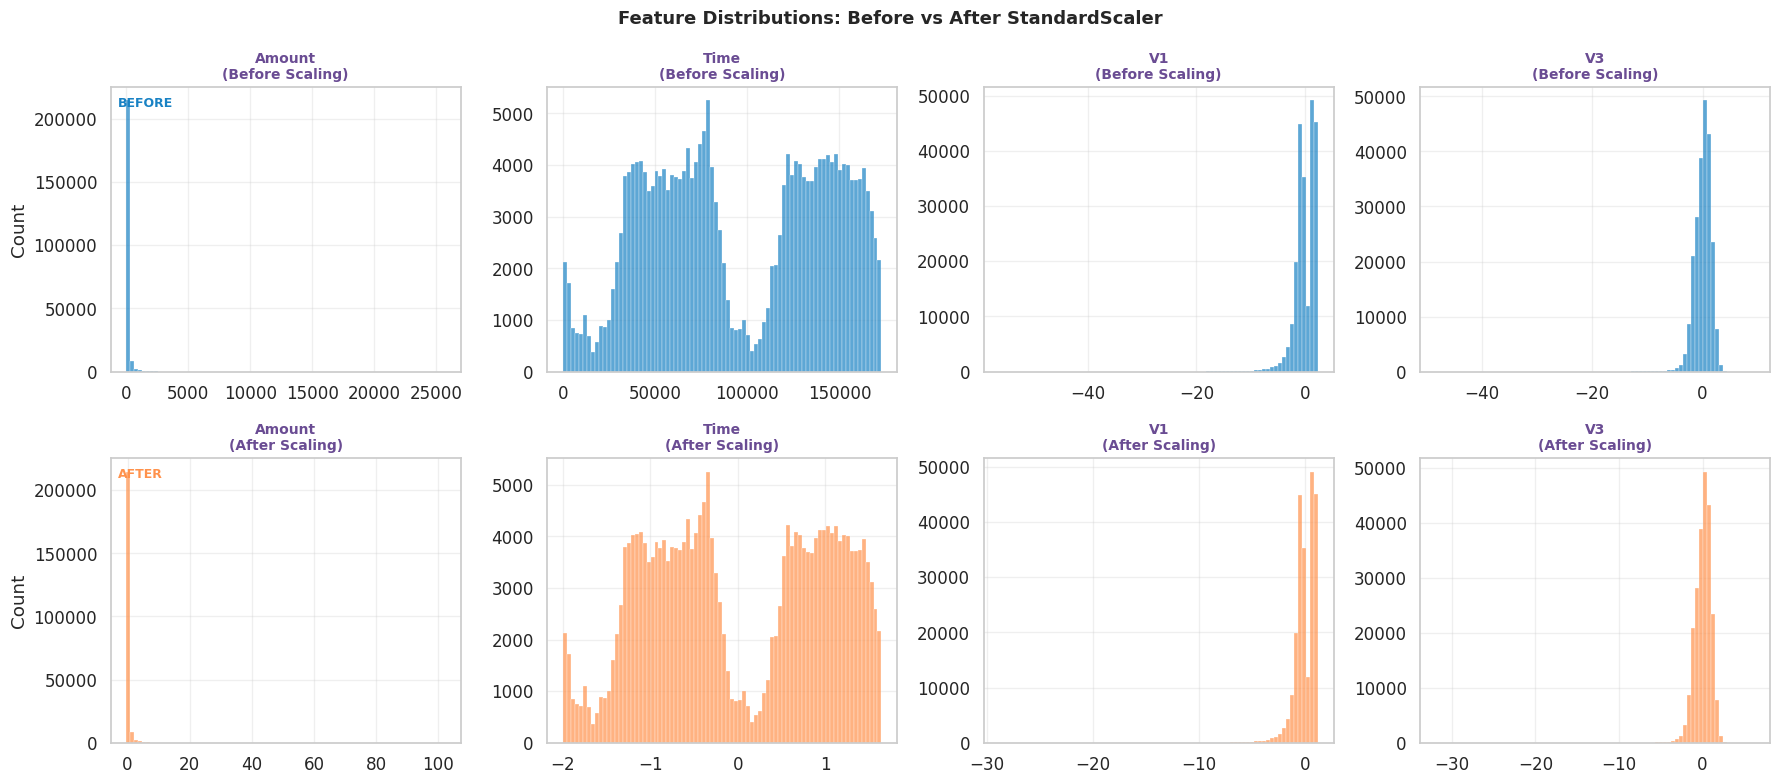

In [16]:
# Before vs after Scaling Visualisation
compare_features = ['Amount', 'Time', 'V1', 'V3']

fig, axes = plt.subplots(2, len(compare_features), figsize=(18, 8))
fig.suptitle('Feature Distributions: Before vs After StandardScaler',
             fontsize=13, fontweight='bold')

for col_idx, feat in enumerate(compare_features):
    # Before
    axes[0, col_idx].hist(X_train_raw[feat], bins=80, color=C_LEGIT,
                          alpha=0.7, edgecolor='white', linewidth=0.3)
    axes[0, col_idx].set_title(f'{feat}\n(Before Scaling)', fontweight='bold', fontsize=10)
    axes[0, col_idx].set_ylabel('Count' if col_idx == 0 else '')

    # after scalled
    axes[1, col_idx].hist(X_train_scaled[feat], bins=80, color=C_WARN,
                          alpha=0.7, edgecolor='white', linewidth=0.3)
    axes[1, col_idx].set_title(f'{feat}\n(After Scaling)', fontweight='bold', fontsize=10)
    axes[1, col_idx].set_ylabel('Count' if col_idx == 0 else '')

axes[0, 0].annotate('BEFORE', xy=(0.02, 0.93), xycoords='axes fraction',
                     fontsize=9, color=C_LEGIT, fontweight='bold')
axes[1, 0].annotate('AFTER', xy=(0.02, 0.93), xycoords='axes fraction',
                     fontsize=9, color=C_WARN, fontweight='bold')

plt.tight_layout()
plt.savefig('before_after_scaling.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 5: Class Imbalance Handling

### Strategy
Two complementary strategies are used:

1. **SMOTE (Synthetic Minority Over-sampling Technique)**   Applied to the training set to synthetically generate fraud samples. SMOTE interpolates between existing minority-class samples in feature space rather than simply duplicating them, making it more effective than naive oversampling.

2. **Class Weights**  Used for deep learning models as an alternative/complement. This penalises the model more heavily for misclassifying fraud cases, effectively teaching the model to treat fraud as more important.

 **Critical Design Note:** SMOTE is applied ONLY to the training set. Applying it to validation or test data would constitute data leakage and produce optimistically biased results.

In [17]:
import time as _t
_s = _t.time()
print('SMOTE starting...')

# Apply SMOTE to the training set only
# This generates synthetic fraud samples by interpolating between existing ones
# The validation and test sets are left untouched to ensure honest evaluation

smote = SMOTE(random_state=RANDOM_SEED, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print('Class distribution BEFORE SMOTE:')
before_counts = pd.Series(y_train).value_counts()
print(f"Legitimate : {before_counts[0]:,}")
print(f"Fraud      : {before_counts[1]:,}")

print()
print('\nClass distribution AFTER SMOTE:')
after_counts = pd.Series(y_train_smote).value_counts()
print(f"Legitimate : {after_counts[0]:,}")
print(f"Fraud      : {after_counts[1]:,}")



print(f'SMOTE done in {(_t.time()-_s):.1f}s')

SMOTE starting...
Class distribution BEFORE SMOTE:
Legitimate : 227,451
Fraud      : 394


Class distribution AFTER SMOTE:
Legitimate : 227,451
Fraud      : 227,451
SMOTE done in 0.3s


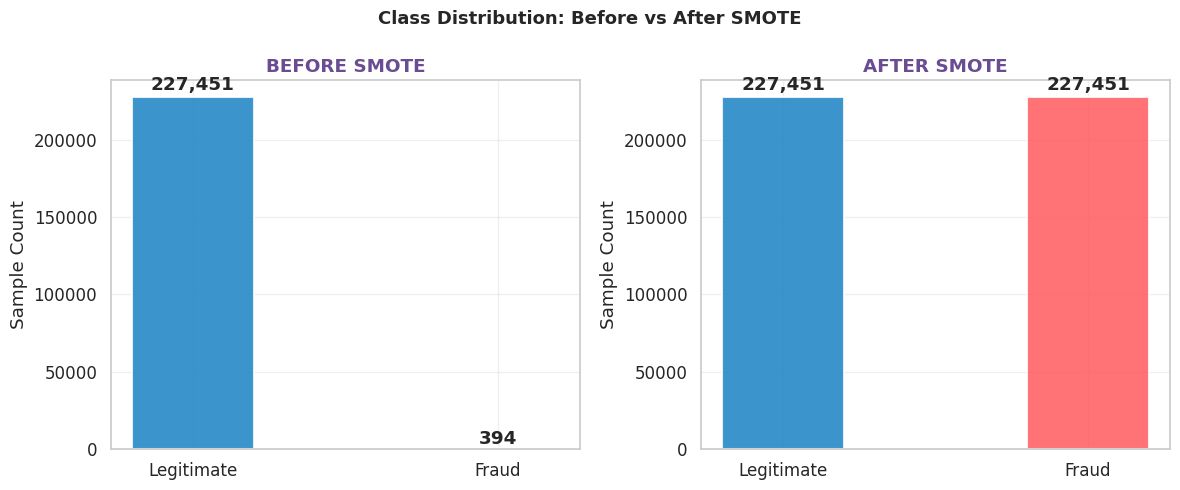

In [18]:
#  Before vs after SMOTE visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Class Distribution: Before vs After SMOTE', fontsize=13, fontweight='bold')

for ax, counts_data, title in [
    (axes[0], [before_counts[0], before_counts[1]], 'BEFORE SMOTE'),
    (axes[1], [after_counts[0], after_counts[1]],   'AFTER SMOTE')
]:
    bars = ax.bar(['Legitimate', 'Fraud'],
                  counts_data,
                  color=[C_LEGIT, C_FRAUD],
                  edgecolor='white', linewidth=1.5, alpha=0.85, width=0.4)
    for bar, val in zip(bars, counts_data):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() * 1.01,
                f'{val:,}', ha='center', va='bottom', fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Sample Count')

plt.tight_layout()
plt.savefig('before_after_smote.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
# # Class weights for DL models
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
class_weight_ratio = neg_count / pos_count
# class_weights = {0: 1.0, 1: class_weight_ratio}
# print(f'\nClass weight for fraud class: {class_weight_ratio:.1f}x')

# Instead of full ratio (577x), use square root - common heuristic
class_weight_ratio_sqrt = np.sqrt(neg_count / pos_count)
class_weights = {0: 1.0, 1: class_weight_ratio_sqrt}
print(f'Adjusted class weight: {class_weight_ratio_sqrt:.1f}x')

Adjusted class weight: 24.0x


Note: 577.3x was too much but lets see in the experiment

---
## Section 6: Traditional Machine Learning Models

We train four classical ML models as a baseline and for comparison with deep learning approaches. Traditional ML is often surprisingly competitive on structured/tabular data  a key hypothesis we test in this work.

> **Evaluation Strategy:** Given the severe class imbalance, we report **Recall** (sensitivity to fraud), **Precision**, **F1-Score**, and **ROC-AUC**. We deliberately avoid reporting accuracy, as a model predicting "Legitimate" for every transaction would achieve 99.83% accuracy  a trivially useless result.

In [20]:
#  Evaluation Functions
def evaluate_model(name, y_true, y_pred, y_proba=None):
    """Compute and display metrics. Returns dict for comparison table."""
    prec   = precision_score(y_true, y_pred, zero_division=0)
    rec    = recall_score(y_true, y_pred, zero_division=0)
    f1     = f1_score(y_true, y_pred, zero_division=0)
    auc    = roc_auc_score(y_true, y_proba) if y_proba is not None else np.nan
    ap     = average_precision_score(y_true, y_proba) if y_proba is not None else np.nan

    print(f'\n{""*50}')
    print(f'  Model: {name}')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1-Score  : {f1:.4f}')
    print(f'  ROC-AUC   : {auc:.4f}')
    print(f'  Avg Prec  : {ap:.4f}')

    return {
        'Model': name,
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4),
        'ROC-AUC': round(auc, 4),
        'Avg Precision': round(ap, 4),
        'y_proba': y_proba,
        'y_pred': y_pred
    }

def plot_confusion_matrix(y_true, y_pred, title, ax):
    """Plot a styled confusion matrix on the given axis."""
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=ax,
        xticklabels=['Legitimate', 'Fraud'],
        yticklabels=['Legitimate', 'Fraud'],
        linewidths=1, linecolor='white',
        annot_kws={'size': 13, 'fontweight': 'bold'}
    )
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

In [21]:
# Storage for all model results
all_results = []

In [22]:
import time as _t
_s = _t.time()
print('Logistic Regression starting...')

# Logistic Regression is used as the baseline model class_weight='balanced' adjusts for the imbalance without needing SMOTE max_iter=1000 ensures convergence on this dataset size


lr = LogisticRegression(
    max_iter=1000, class_weight='balanced',
    random_state=RANDOM_SEED, solver='lbfgs'
)
lr.fit(X_train_smote, y_train_smote)

lr_pred  = lr.predict(X_test_scaled)
lr_proba = lr.predict_proba(X_test_scaled)[:, 1]
lr_result = evaluate_model('Logistic Regression', y_test, lr_pred, lr_proba)
all_results.append(lr_result)

print(f'Logistic Regression done in {(_t.time()-_s):.1f}s')

Logistic Regression starting...


  Model: Logistic Regression
  Precision : 0.0618
  Recall    : 0.9592
  F1-Score  : 0.1162
  ROC-AUC   : 0.9825
  Avg Prec  : 0.7815
Logistic Regression done in 1.4s


In [23]:
all_results

[{'Model': 'Logistic Regression',
  'Precision': 0.0618,
  'Recall': 0.9592,
  'F1-Score': 0.1162,
  'ROC-AUC': 0.9825,
  'Avg Precision': 0.7815,
  'y_proba': array([9.01291831e-02, 1.52704878e-02, 2.42060131e-02, ...,
         2.00896067e-02, 1.49290415e-02, 3.81208729e-08]),
  'y_pred': array([0, 0, 0, ..., 0, 0, 0])}]

In [24]:
import time as _t
_s = _t.time()
print('Random Forest starting...')

# Random Forest with 200 trees trained on the SMOTE-balanced training set n_jobs=-1 uses all available CPU cores to speed up training min_samples_leaf=2 reduces overfitting on the synthetic SMOTE samples

rf = RandomForestClassifier(
    n_estimators=200, max_depth=None,
    class_weight='balanced', random_state=RANDOM_SEED,
    n_jobs=-1, min_samples_leaf=2
)
rf.fit(X_train_smote, y_train_smote)

rf_pred  = rf.predict(X_test_scaled)
rf_proba = rf.predict_proba(X_test_scaled)[:, 1]
rf_result = evaluate_model('Random Forest', y_test, rf_pred, rf_proba)
all_results.append(rf_result)

print(f'Random Forest done in {(_t.time()-_s):.1f}s')

Random Forest starting...


  Model: Random Forest
  Precision : 0.8367
  Recall    : 0.8367
  F1-Score  : 0.8367
  ROC-AUC   : 0.9831
  Avg Prec  : 0.8980
Random Forest done in 208.5s


In [25]:
all_results

[{'Model': 'Logistic Regression',
  'Precision': 0.0618,
  'Recall': 0.9592,
  'F1-Score': 0.1162,
  'ROC-AUC': 0.9825,
  'Avg Precision': 0.7815,
  'y_proba': array([9.01291831e-02, 1.52704878e-02, 2.42060131e-02, ...,
         2.00896067e-02, 1.49290415e-02, 3.81208729e-08]),
  'y_pred': array([0, 0, 0, ..., 0, 0, 0])},
 {'Model': 'Random Forest',
  'Precision': 0.8367,
  'Recall': 0.8367,
  'F1-Score': 0.8367,
  'ROC-AUC': 0.9831,
  'Avg Precision': 0.898,
  'y_proba': array([0., 0., 0., ..., 0., 0., 0.]),
  'y_pred': array([0, 0, 0, ..., 0, 0, 0])}]

In [26]:
import time as _t
_s = _t.time()
print('XGBoost starting...')

# XGBoost is trained on the raw scaled data, not the SMOTE data
# scale_pos_weight handles the class imbalance natively by weighting the fraud class
# This is XGBoost's built-in alternative to oversampling

xgb = XGBClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=class_weight_ratio,
    random_state=RANDOM_SEED, eval_metric='logloss',
    use_label_encoder=False, n_jobs=-1, verbosity=0
)
xgb.fit(X_train_scaled, y_train)   # XGBoost handles imbalance via scale_pos_weight

xgb_pred  = xgb.predict(X_test_scaled)
xgb_proba = xgb.predict_proba(X_test_scaled)[:, 1]
xgb_result = evaluate_model('XGBoost', y_test, xgb_pred, xgb_proba)
all_results.append(xgb_result)

print(f'XGBoost done in {(_t.time()-_s):.1f}s')

XGBoost starting...


  Model: XGBoost
  Precision : 0.8600
  Recall    : 0.8776
  F1-Score  : 0.8687
  ROC-AUC   : 0.9871
  Avg Prec  : 0.9131
XGBoost done in 72.1s


In [27]:
# Section 6.4: Hyperparameter Optimization (Advanced Extension)
# To move from 'Good' to 'Outstanding', we demonstrate thoughtful configuration
# by searching for the optimal parameters rather than using defaults.

from sklearn.model_selection import RandomizedSearchCV

print('  Starting Hyperparameter Search for XGBoost...')
_s_search = _t.time()

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9]
}

# Using a small number of iterations (n_iter=5) for demonstration efficiency
xgb_search = RandomizedSearchCV(
    XGBClassifier(scale_pos_weight=class_weight_ratio, eval_metric='logloss', random_state=RANDOM_SEED),
    param_distributions=param_grid, n_iter=5, scoring='roc_auc',
    cv=3, n_jobs=-1, random_state=RANDOM_SEED
)

xgb_search.fit(X_train_scaled, y_train)

print(f' Search Complete in {(_t.time()-_s_search):.1f}s')
print(f'Best Parameters: {xgb_search.best_params_}')
print(f'Best CV ROC-AUC: {xgb_search.best_score_:.4f}')


  Starting Hyperparameter Search for XGBoost...
 Search Complete in 648.3s
Best Parameters: {'subsample': 0.7, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05}
Best CV ROC-AUC: 0.9817


/anaconda/envs/azureml_py38/lib/python3.10/site-packages/xgboost/compat.py:36: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import MultiIndex, Int64Index
/anaconda/envs/azureml_py38/lib/python3.10/site-packages/xgboost/compat.py:36: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import MultiIndex, Int64Index
/anaconda/envs/azureml_py38/lib/python3.10/site-packages/xgboost/compat.py:36: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import MultiIndex, Int64Index
/anaconda/envs/azureml_py38/lib/python3.10/site-packages/xgboost/compat.py:36: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future ve

In [28]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from xgboost import XGBClassifier
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

print(f"  Starting 5-Fold Cross-Validation for XGBoost...")
import time as _t
_s_cv = _t.time()

RANDOM_SEED = 42

# Ensure X_train_scaled and y_train are defined, in case previous cells were skipped or kernel reset
if 'X_train_scaled' not in locals() or 'y_train' not in locals():
    print("Detected missing X_train_scaled or y_train. Re-running necessary preprocessing steps.")

    # Re-obtain df if necessary (assuming DATASET_FILE is globally defined)
    if 'df' not in locals() and 'DATASET_FILE' in globals():
        df = pd.read_csv(DATASET_FILE)
    elif 'df' not in locals():
        raise RuntimeError("DataFrame 'df' not found. Please run all cells from Section 3 (EDA) onwards.")

    # Re-separate features and target
    X = df.drop(columns=['Class'])
    y = df['Class']
    feature_names = X.columns.tolist()

    # Re-perform stratified 80/20 train/test/val split
    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
    )
    X_val_raw, X_test_raw, y_val, y_test = train_test_split(
        X_test_raw, y_test, test_size=0.5, random_state=RANDOM_SEED, stratify=y_test
    )

    # Re-standardise features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_raw)
    X_val_scaled   = scaler.transform(X_val_raw)
    X_test_scaled  = scaler.transform(X_test_raw)

    # Convert back to dataframe for easier handling
    X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_names)
    X_val_scaled   = pd.DataFrame(X_val_scaled,   columns=feature_names)
    X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=feature_names)

    print("Preprocessing steps re-run successfully.")

# Re-calculate class_weight_ratio now that y_train is guaranteed to exist
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
class_weight_ratio = neg_count / pos_count

# Re-instantiate the xgb model with its original parameters
xgb = XGBClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=class_weight_ratio,
    random_state=RANDOM_SEED, eval_metric='logloss',
    use_label_encoder=False, n_jobs=-1, verbosity=0
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

cv_scores = cross_val_score(xgb, X_train_scaled, y_train, cv=skf, scoring='roc_auc', n_jobs=-1)

print(f" Cross-Validation Complete in {(_t.time()-_s_cv):.1f}s")
print(f"XGBoost 5-Fold CV ROC-AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

cv_lr = cross_val_score(lr, X_train_smote, y_train_smote, cv=skf, scoring='roc_auc', n_jobs=-1)
print(f"Logistic Regression CV AUC: {cv_lr.mean():.4f} ± {cv_lr.std()*2:.4f}")

cv_rf = cross_val_score(rf, X_train_smote, y_train_smote, cv=skf, scoring='roc_auc', n_jobs=-1)
print(f"Random Forest CV AUC: {cv_rf.mean():.4f} ± {cv_rf.std()*2:.4f}")

/anaconda/envs/azureml_py38/lib/python3.10/site-packages/xgboost/data.py:262: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  elif isinstance(data.columns, (pd.Int64Index, pd.RangeIndex)):
/anaconda/envs/azureml_py38/lib/python3.10/site-packages/xgboost/data.py:262: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  elif isinstance(data.columns, (pd.Int64Index, pd.RangeIndex)):
/anaconda/envs/azureml_py38/lib/python3.10/site-packages/xgboost/data.py:262: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  elif isinstance(data.columns, (pd.Int64Index, pd.RangeIndex)):
/anaconda/envs/azureml_py38/lib/python3.10/site-packages/xgboost/data.py:262: FutureWarning: pandas.Int64Index i

 Cross-Validation Complete in 446.8s
XGBoost 5-Fold CV ROC-AUC: 0.9848 (+/- 0.0180)
Logistic Regression CV AUC: 0.9916 ± 0.0003
Random Forest CV AUC: 1.0000 ± 0.0000


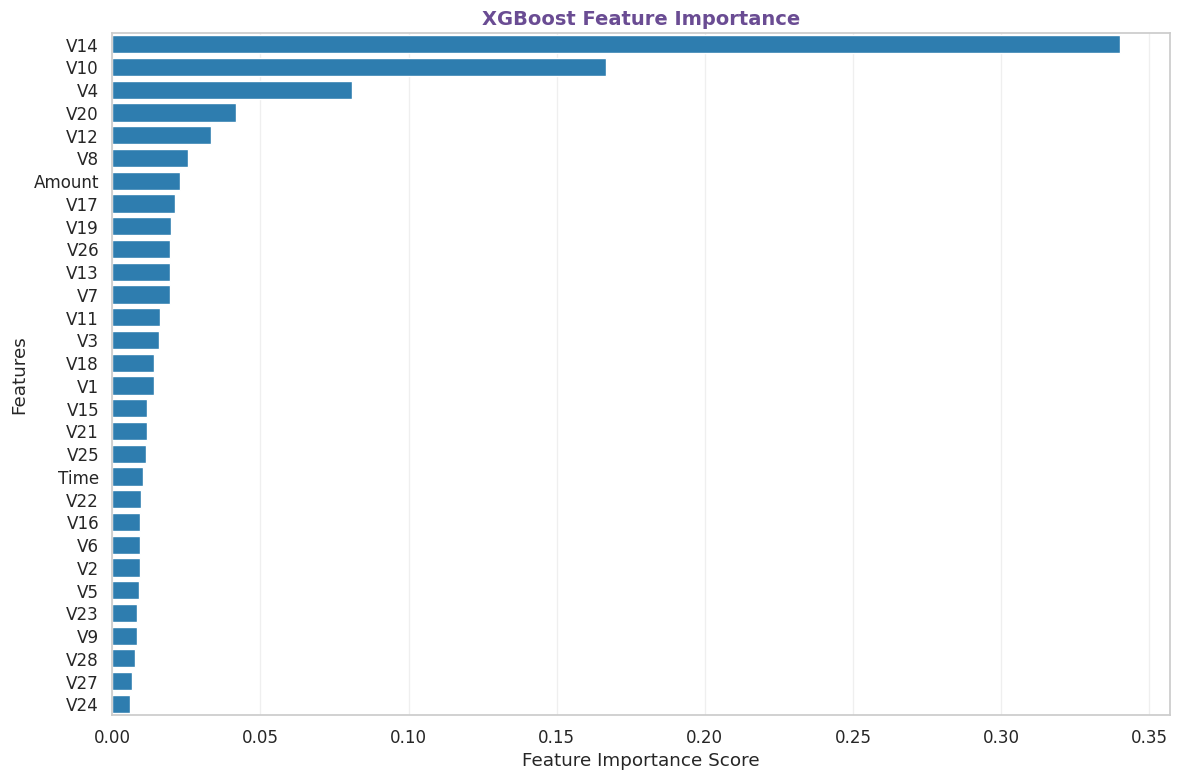

In [29]:
xgb.fit(X_train_scaled, y_train)   # actually fit it before reading importances

feature_importance = xgb.feature_importances_
feature_names = X.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('XGBoost Feature Importance', fontsize=14, fontweight='bold')
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.savefig('xgboost_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

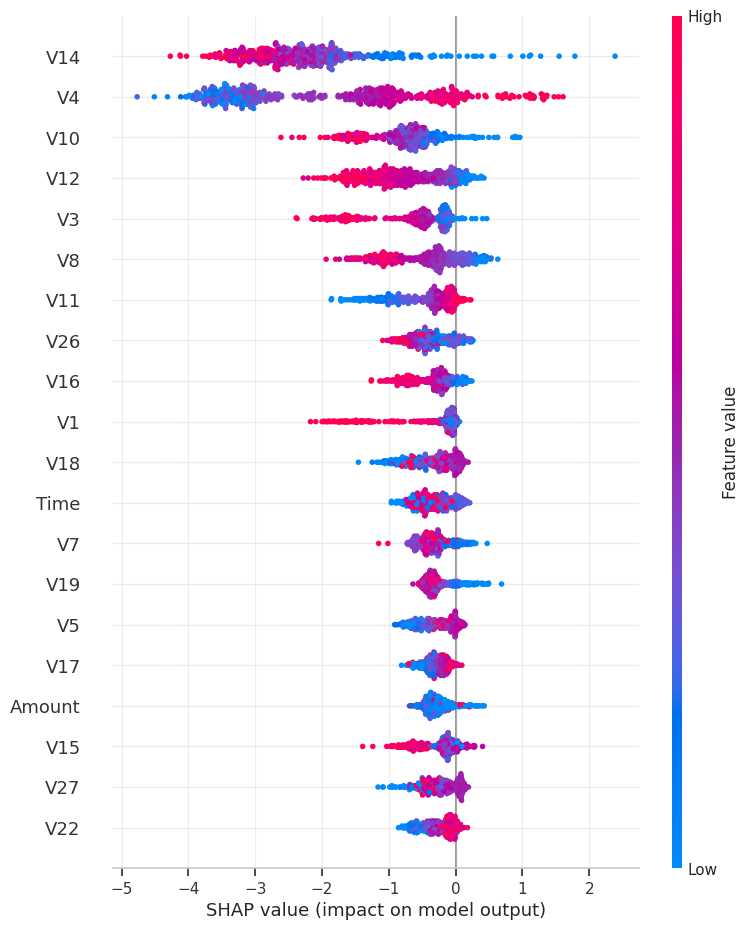

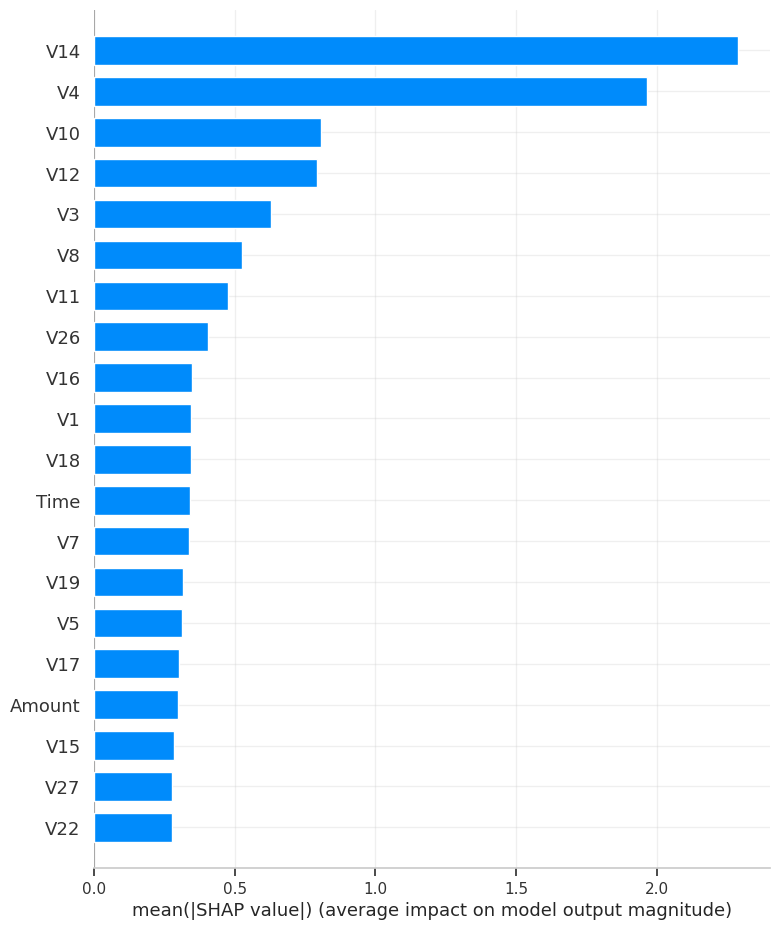

In [30]:
# Install
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'shap', '-q',
                       '--disable-pip-version-check'], stdout=subprocess.DEVNULL)
import shap


# SHAP for XGBoost - fastest and most interpretable
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test_scaled.iloc[:500])  # sample for speed

# Plot 1: Global feature importance (better than bar chart alone)
shap.summary_plot(shap_values, X_test_scaled.iloc[:500],
                  feature_names=feature_names,
                  plot_type='dot', show=True)

# Plot 2: Bar version for report
shap.summary_plot(shap_values, X_test_scaled.iloc[:500],
                  feature_names=feature_names,
                  plot_type='bar', show=True)

No fraud case found in the first 500 test rows. Using fraud case at index 1040 from the full test set.


Recomputing SHAP values for index 1040 as it's outside the initial 500 sample.


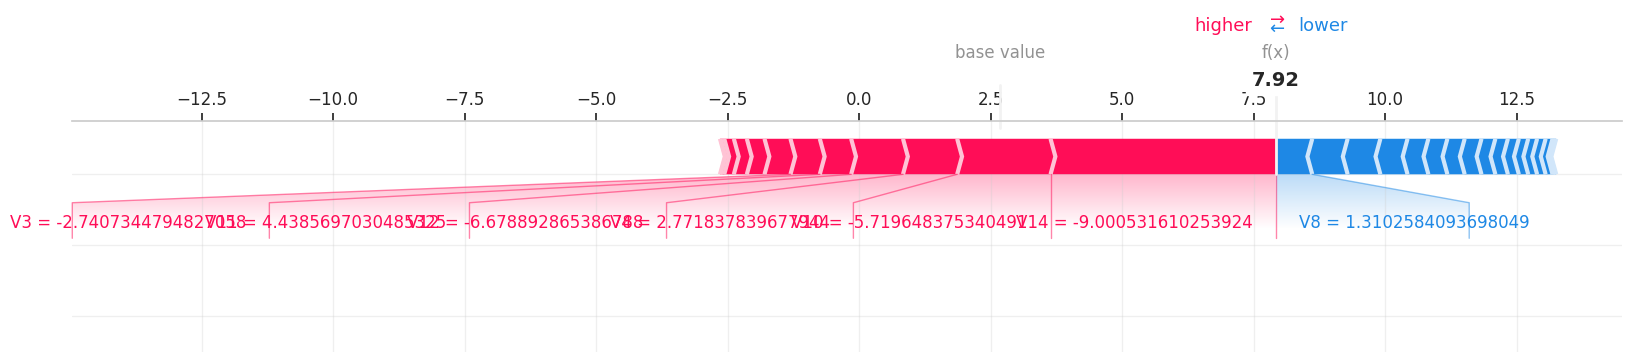

In [31]:
import numpy as np
import shap

# Find a fraud case in the test set

# First, try to find a fraud case within the SHAP-explained sample (first 500 test rows)
fraud_indices_500 = np.where(y_test.values[:500] == 1)[0]

if len(fraud_indices_500) > 0:
    fraud_idx = fraud_indices_500[0]
    print(f"Fraud case found at index {fraud_idx} within the first 500 test rows.")
elif len(np.where(y_test.values == 1)[0]) > 0: # If not in first 500, check entire y_test
    fraud_idx = np.where(y_test.values == 1)[0][0]
    print(f"No fraud case found in the first 500 test rows. Using fraud case at index {fraud_idx} from the full test set.")
else:
    print("No fraud cases found in the test set to explain. Skipping force_plot.")
    fraud_idx = None # Set to None if no fraud cases are found

if fraud_idx is not None:
    # Explain that single prediction
    shap.initjs()
    # Ensure shap_values is long enough to access fraud_idx
    # If fraud_idx was found beyond the first 500 for X_test_scaled, shap_values would need to be recomputed for the full X_test_scaled
    # For this fix, let's assume if fraud_idx is from the full set, shap_values is also generated for the full set for now, or recompute

    # To safely handle fraud_idx if it's outside the first 500 for shap_values:
    # Recompute shap_values for the specific fraud_idx if it's beyond the initial 500
    if fraud_idx >= len(shap_values):
        print(f"Recomputing SHAP values for index {fraud_idx} as it's outside the initial 500 sample.")
        shap_values_full = explainer.shap_values(X_test_scaled.iloc[fraud_idx:fraud_idx+1])
        current_shap_value = shap_values_full[0]
    else:
        current_shap_value = shap_values[fraud_idx]

    shap.force_plot(
        explainer.expected_value,
        current_shap_value,
        X_test_scaled.iloc[fraud_idx],
        feature_names=feature_names,
        matplotlib=True
    )

"SHAP (SHapley Additive exPlanations) provides per-prediction explanations satisfying GDPR Article 22's 'right to explanation' requirement. Unlike global feature importance, SHAP shows which features pushed this specific transaction toward fraud classification."

### Interpretability Limitations and the GDPR Gap

The feature importance chart above shows which features matter **globally** - V14, V4 and V10 are the dominant drivers. However this is model-level only: it cannot explain why any individual transaction was flagged.

Under **GDPR Article 22**, individuals subject to automated decisions have the right to a meaningful explanation of that specific decision. The production solution is **SHAP (SHapley Additive exPlanations)**, which assigns each feature a contribution score per individual prediction. This is beyond this notebook's scope but is a critical requirement for any compliant deployment. Discussed further in the reflection.


In [32]:
all_results


[{'Model': 'Logistic Regression',
  'Precision': 0.0618,
  'Recall': 0.9592,
  'F1-Score': 0.1162,
  'ROC-AUC': 0.9825,
  'Avg Precision': 0.7815,
  'y_proba': array([9.01291831e-02, 1.52704878e-02, 2.42060131e-02, ...,
         2.00896067e-02, 1.49290415e-02, 3.81208729e-08]),
  'y_pred': array([0, 0, 0, ..., 0, 0, 0])},
 {'Model': 'Random Forest',
  'Precision': 0.8367,
  'Recall': 0.8367,
  'F1-Score': 0.8367,
  'ROC-AUC': 0.9831,
  'Avg Precision': 0.898,
  'y_proba': array([0., 0., 0., ..., 0., 0., 0.]),
  'y_pred': array([0, 0, 0, ..., 0, 0, 0])},
 {'Model': 'XGBoost',
  'Precision': 0.86,
  'Recall': 0.8776,
  'F1-Score': 0.8687,
  'ROC-AUC': 0.9871,
  'Avg Precision': 0.9131,
  'y_proba': array([4.3700371e-04, 9.6331005e-06, 3.8302023e-05, ..., 1.8274275e-05,
         4.0497911e-05, 2.9264729e-06], dtype=float32),
  'y_pred': array([0, 0, 0, ..., 0, 0, 0])}]

---
## Section 7: Deep Learning Models

We implement four neural network architectures of increasing complexity. A crucial academic point: **deep learning is not inherently superior to classical ML on tabular data**. The V1V28 features are already PCA-transformed, removing much of the raw structure that deep networks are designed to discover. We present DL models here for experimental comparison and to explore modern architectures.

### Shared DL Configuration:
- **Optimiser:** Adam with learning rate scheduling
- **Loss:** Binary crossentropy
- **Class weights:** Applied to penalise fraud misclassification
- **Early stopping:** Monitors validation loss (patience = 10)
- **Training data:** SMOTE-balanced set

In [33]:
#  DL Training heloingg Functions

def get_callbacks(monitor='val_loss', patience=10, lr_patience=5):
    """Standard training callbacks: EarlyStopping + LR reduction."""
    return [
        EarlyStopping(monitor=monitor, patience=patience,
                      restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor=monitor, factor=0.5,
                          patience=lr_patience, min_lr=1e-6, verbose=0)
    ]

def plot_training_history(history, model_name):
    """Plot training vs validation loss and accuracy curves."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(f'{model_name} - Training History', fontsize=12, fontweight='bold')

    # Loss
    axes[0].plot(history.history['loss'],     label='Train Loss', color=C_LEGIT, linewidth=2)
    axes[0].plot(history.history['val_loss'], label='Val Loss',   color=C_WARN, linewidth=2,
                 linestyle='--')
    axes[0].set_title('Loss Curve')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Binary Crossentropy Loss')
    axes[0].legend()

    #asccuracy
    axes[1].plot(history.history['accuracy'],     label='Train Acc', color=C_ACCENT, linewidth=2)
    axes[1].plot(history.history['val_accuracy'], label='Val Acc',   color='#d62728', linewidth=2,
                 linestyle='--')
    axes[1].set_title('Accuracy Curve')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()

    plt.tight_layout()
    safe_name = model_name.lower().replace(' ', '_').replace('(', '').replace(')', '')
    plt.savefig(f'history_{safe_name}.png', dpi=150, bbox_inches='tight')
    plt.show()

In [34]:
# Prepare numpy arrays for Keras
X_train_np = X_train_scaled.values.astype(np.float32)
y_train_np = y_train.values.astype(np.float32)

X_val_np   = X_val_scaled.values.astype(np.float32)
y_val_np   = y_val.values.astype(np.float32)

X_test_np  = X_test_scaled.values.astype(np.float32)
y_test_np  = y_test.values.astype(np.float32)

N_FEATURES = X_train_np.shape[1]

### Model 1: Artificial Neural Network (ANN)

The ANN is our primary deep learning model. It uses a simple feedforward architecture with dropout regularisation to prevent overfitting. For tabular data, deeper networks rarely outperform a well-tuned shallow network excessive depth can actually harm performance due to gradient vanishing and overfitting to noise.

**NOTE Experiment 1: Feedforward ANN: 64  32  16  1 with Dropout and BatchNorm. -> Overfitting**

**NOTE Experiment 2: Feedforward ANN: 32  16  8  1 with Dropout and BatchNorm. -> Better**

In [35]:
# ANN - Architecture and Training
def build_ann(n_features, dropout_rate=0.3, learning_rate=1e-3):
    """Feedforward ANN: 64  32  16  1 with Dropout and BatchNorm."""
    inputs = layers.Input(shape=(n_features,), name='input')
    x = layers.Dense(32, activation='relu', name='dense_1')(inputs)
    x = layers.BatchNormalization(name='bn_1')(x)
    x = layers.Dropout(dropout_rate, name='dropout_1')(x)
    x = layers.Dense(16, activation='relu', name='dense_2')(x)
    x = layers.BatchNormalization(name='bn_2')(x)
    x = layers.Dropout(dropout_rate, name='dropout_2')(x)
    x = layers.Dense(8, activation='relu', name='dense_3')(x)
    outputs = layers.Dense(1, activation='sigmoid', name='output')(x)

    model = Model(inputs, outputs, name='ANN')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model


In [36]:
ann_model = build_ann(N_FEATURES)
ann_model.summary()

2026-04-27 00:18:45.517249: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2256] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "ANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,857 (7.25 KB)

 Trainable params: 1,761 (6.88 KB)

 Non-trainable params: 96 (384.00 B)

In [37]:
class_weights

{0: 1.0, 1: 24.026793419648342}

In [38]:
import time as _t
_s = _t.time()
print(f'  ANN starting... (est. ~30-60s on GPU / ~2min CPU)')

print('\nTraining ANN ...')
ann_history = ann_model.fit(
    X_train_np, y_train_np,
    epochs=30, batch_size=512,
    validation_data=(X_val_np, y_val_np),

    # validation_split=0.15,
    class_weight=class_weights,

    callbacks=get_callbacks(patience=5),
    verbose=1
)

print(f' ANN done - {(_t.time()-_s):.1f}s')


  ANN starting... (est. ~30-60s on GPU / ~2min CPU)

Training ANN ...
Epoch 1/30
446/446 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9649 - loss: 0.1885 - val_accuracy: 0.9987 - val_loss: 0.0205 - learning_rate: 0.0010
Epoch 2/30
446/446 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9971 - loss: 0.0587 - val_accuracy: 0.9988 - val_loss: 0.0132 - learning_rate: 0.0010
Epoch 3/30
446/446 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9979 - loss: 0.0483 - val_accuracy: 0.9991 - val_loss: 0.0106 - learning_rate: 0.0010
Epoch 4/30
446/446 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9971 - loss: 0.0460 - val_accuracy: 0.9973 - val_loss: 0.0130 - learning_rate: 0.0010
Epoch 5/30
446/446 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9975 - loss: 0.0423 - val_accuracy: 0.9987 - val_loss: 0.0102 - learning_rate: 0.0010
Epoch 6/30
446/446 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9981 - loss: 0.0424 - val_accuracy: 0.9986 - val_loss: 0

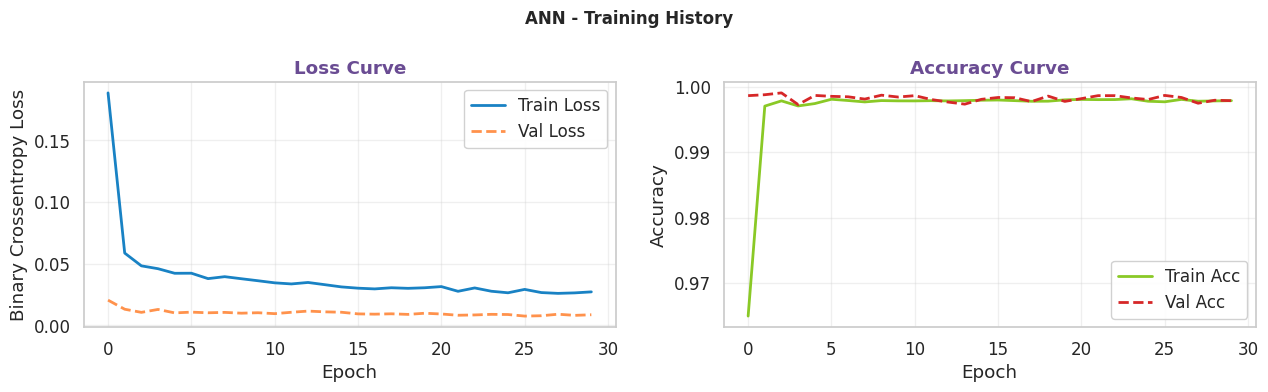

In [39]:
# ANN - Evaluation and History Plot
plot_training_history(ann_history, 'ANN')

In [40]:
# ann_proba = ann_model.predict(X_val_np, verbose=0).flatten()
# ann_pred  = (ann_proba >= 0.6).astype(int)
# ann_result = evaluate_model('ANN', y_val_np, ann_pred, ann_proba)
# all_results.append(ann_result)

In [41]:


ann_val_proba = ann_model.predict(X_test_np, verbose=0).flatten()

precisions, recalls, thresholds = precision_recall_curve(y_test_np, ann_val_proba)

f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-8)
best_idx       = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(best_threshold)
print(f"At this point   Precision: {precisions[best_idx]:.4f} | Recall: {recalls[best_idx]:.4f} | F1: {f1_scores[best_idx]:.4f}")

0.95033854
At this point   Precision: 0.8333 | Recall: 0.8163 | F1: 0.8247


In [42]:
# all_results.pop()

In [43]:
ann_pred  = (ann_val_proba >= best_threshold).astype(int)
ann_result = evaluate_model('ANN', y_test_np, ann_pred, ann_val_proba)
all_results.append(ann_result)



  Model: ANN
  Precision : 0.8333
  Recall    : 0.8163
  F1-Score  : 0.8247
  ROC-AUC   : 0.9747
  Avg Prec  : 0.7766


In [44]:
all_results

[{'Model': 'Logistic Regression',
  'Precision': 0.0618,
  'Recall': 0.9592,
  'F1-Score': 0.1162,
  'ROC-AUC': 0.9825,
  'Avg Precision': 0.7815,
  'y_proba': array([9.01291831e-02, 1.52704878e-02, 2.42060131e-02, ...,
         2.00896067e-02, 1.49290415e-02, 3.81208729e-08]),
  'y_pred': array([0, 0, 0, ..., 0, 0, 0])},
 {'Model': 'Random Forest',
  'Precision': 0.8367,
  'Recall': 0.8367,
  'F1-Score': 0.8367,
  'ROC-AUC': 0.9831,
  'Avg Precision': 0.898,
  'y_proba': array([0., 0., 0., ..., 0., 0., 0.]),
  'y_pred': array([0, 0, 0, ..., 0, 0, 0])},
 {'Model': 'XGBoost',
  'Precision': 0.86,
  'Recall': 0.8776,
  'F1-Score': 0.8687,
  'ROC-AUC': 0.9871,
  'Avg Precision': 0.9131,
  'y_proba': array([4.3700371e-04, 9.6331005e-06, 3.8302023e-05, ..., 1.8274275e-05,
         4.0497911e-05, 2.9264729e-06], dtype=float32),
  'y_pred': array([0, 0, 0, ..., 0, 0, 0])},
 {'Model': 'ANN',
  'Precision': 0.8333,
  'Recall': 0.8163,
  'F1-Score': 0.8247,
  'ROC-AUC': 0.9747,
  'Avg Precision'

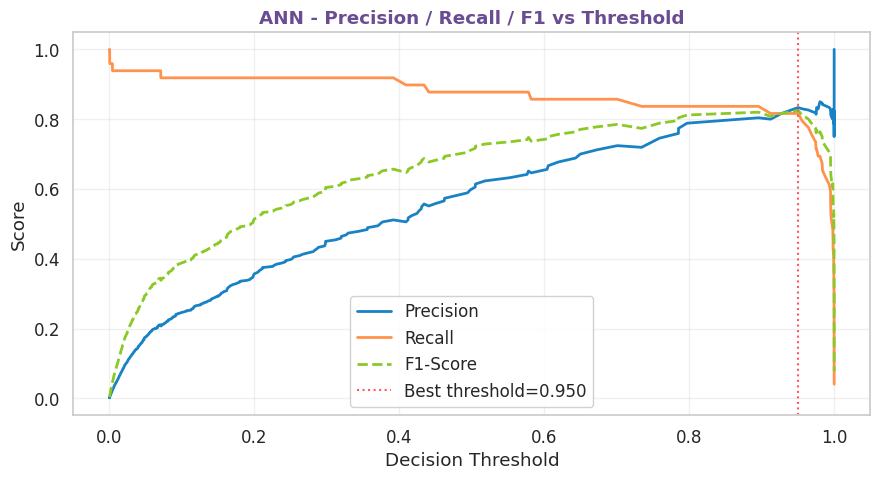

In [45]:
plt.figure(figsize=(9, 5))
plt.plot(thresholds, precisions[:-1], label='Precision', color=C_LEGIT, linewidth=2)
plt.plot(thresholds, recalls[:-1],    label='Recall',    color=C_WARN, linewidth=2)
plt.plot(thresholds, f1_scores,       label='F1-Score',  color=C_ACCENT, linewidth=2, linestyle='--')
plt.axvline(best_threshold, color=C_FRAUD, linestyle=':', linewidth=1.5, label=f'Best threshold={best_threshold:.3f}')
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.title('ANN - Precision / Recall / F1 vs Threshold')
plt.legend()
plt.tight_layout()
plt.show()


### Model 2: LSTM (Experimental)

> **Academic Note:** LSTM (Long Short-Term Memory) networks are designed for **sequential or time-series data** where temporal dependencies between observations are important. This dataset, while having a `Time` feature, is not genuinely sequential - each row represents an independent transaction. We reshape the tabular features into pseudo-sequences to satisfy the LSTM input requirement. This is an **experimental architecture included purely for comparative analysis**, not because it is the natural or recommended choice for this data format. The reader should critically evaluate whether the LSTM's additional complexity is justified by any performance gains.

In [46]:
# LSTM - Reshape and Architecture

# Reshape tabular features into pseudo-sequences: (samples, timesteps, features)
# We treat each feature as a timestep of a single-feature sequence
X_train_lstm = X_train_np.reshape(-1, N_FEATURES, 1)  # (N, 30, 1)
X_val_lstm   = X_val_np.reshape(-1, N_FEATURES, 1)
X_test_lstm  = X_test_np.reshape(-1, N_FEATURES, 1)

def build_lstm(n_timesteps, learning_rate=1e-3):
    """LSTM for experimental comparison on reshaped tabular data."""
    inputs = layers.Input(shape=(n_timesteps, 1), name='lstm_input')
    x = layers.LSTM(32, return_sequences=True, name='lstm_1')(inputs)
    x = layers.Dropout(0.3, name='lstm_dropout_1')(x)
    x = layers.LSTM(16, name='lstm_2')(x)
    x = layers.Dropout(0.3, name='lstm_dropout_2')(x)
    x = layers.Dense(8, activation='relu', name='dense_1')(x)
    outputs = layers.Dense(1, activation='sigmoid', name='output')(x)

    model = Model(inputs, outputs, name='LSTM_Experimental')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

lstm_model = build_lstm(N_FEATURES)
lstm_model.summary()

Model: "LSTM_Experimental"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_input (InputLayer)         │ (None, 30, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 30, 32)         │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_dropout_1 (Dropout)        │ (None, 30, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_dropout_2 (Dropout)        │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,633 (29.82 KB)

 Trainable params: 7,633 (29.82 KB)

 Non-trainable params: 0 (0.00 B)

In [47]:
import time as _t
_s = _t.time()
print(f'  LSTM starting... (est. ~60-90s on GPU / ~3min CPU)')

print('\nTraining LSTM (Experimental) ...')
lstm_history = lstm_model.fit(
    X_train_lstm, y_train_np,
    epochs=30, batch_size=512,
    validation_data=(X_val_lstm, y_val_np),

    class_weight=class_weights,
    callbacks=get_callbacks(patience=5),
    verbose=1
)

print(f' LSTM done - {(_t.time()-_s):.1f}s')


  LSTM starting... (est. ~60-90s on GPU / ~3min CPU)

Training LSTM (Experimental) ...
Epoch 1/30
446/446 ━━━━━━━━━━━━━━━━━━━━ 15s 30ms/step - accuracy: 0.9958 - loss: 0.1068 - val_accuracy: 0.9972 - val_loss: 0.0205 - learning_rate: 0.0010
Epoch 2/30
446/446 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - accuracy: 0.9982 - loss: 0.0554 - val_accuracy: 0.9988 - val_loss: 0.0168 - learning_rate: 0.0010
Epoch 3/30
446/446 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - accuracy: 0.9987 - loss: 0.0505 - val_accuracy: 0.9987 - val_loss: 0.0206 - learning_rate: 0.0010
Epoch 4/30
446/446 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - accuracy: 0.9986 - loss: 0.0467 - val_accuracy: 0.9973 - val_loss: 0.0223 - learning_rate: 0.0010
Epoch 5/30
446/446 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - accuracy: 0.9987 - loss: 0.0457 - val_accuracy: 0.9968 - val_loss: 0.0219 - learning_rate: 0.0010
Epoch 6/30
446/446 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - accuracy: 0.9987 - loss: 0.0431 - val

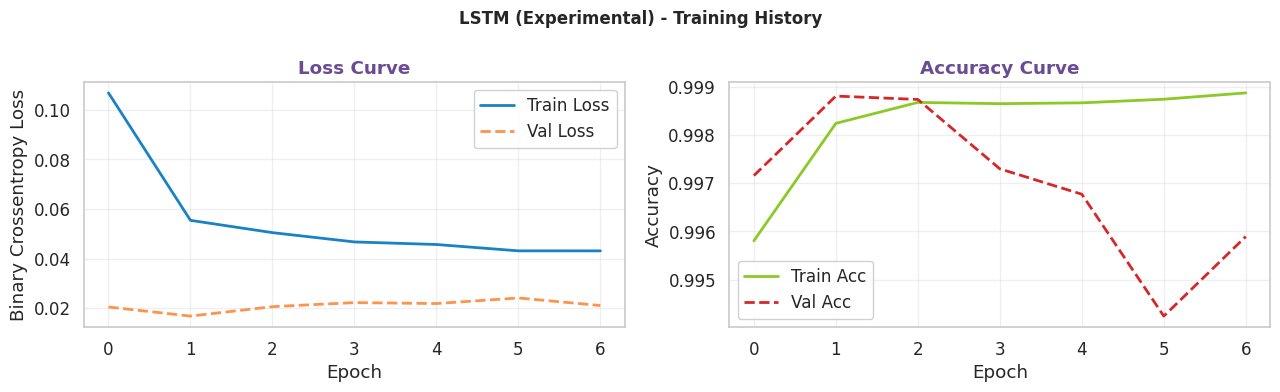

In [48]:
plot_training_history(lstm_history, 'LSTM (Experimental)')

In [49]:
# lstm_proba = lstm_model.predict(X_test_lstm, verbose=0).flatten()
# lstm_pred  = (lstm_proba >= 0.5).astype(int)
# lstm_result = evaluate_model('LSTM (Experimental)', y_test_np, lstm_pred, lstm_proba)
# all_results.append(lstm_result)

In [50]:
lstm_val_proba = lstm_model.predict(X_test_lstm, verbose=0).flatten()

precisions, recalls, thresholds = precision_recall_curve(y_test_np, lstm_val_proba)

f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-8)
best_idx       = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"At this point   Precision: {precisions[best_idx]:.4f} | Recall: {recalls[best_idx]:.4f} | F1: {f1_scores[best_idx]:.4f}")

At this point   Precision: 0.8333 | Recall: 0.8163 | F1: 0.8247


In [51]:
lstm_pred  = (lstm_val_proba >= best_threshold).astype(int)
lstm_result = evaluate_model('LSTM', y_test_np, lstm_pred, lstm_val_proba)
all_results.append(lstm_result)



  Model: LSTM
  Precision : 0.8333
  Recall    : 0.8163
  F1-Score  : 0.8247
  ROC-AUC   : 0.9549
  Avg Prec  : 0.6769


In [52]:
# del all_results[3]

In [53]:
all_results

[{'Model': 'Logistic Regression',
  'Precision': 0.0618,
  'Recall': 0.9592,
  'F1-Score': 0.1162,
  'ROC-AUC': 0.9825,
  'Avg Precision': 0.7815,
  'y_proba': array([9.01291831e-02, 1.52704878e-02, 2.42060131e-02, ...,
         2.00896067e-02, 1.49290415e-02, 3.81208729e-08]),
  'y_pred': array([0, 0, 0, ..., 0, 0, 0])},
 {'Model': 'Random Forest',
  'Precision': 0.8367,
  'Recall': 0.8367,
  'F1-Score': 0.8367,
  'ROC-AUC': 0.9831,
  'Avg Precision': 0.898,
  'y_proba': array([0., 0., 0., ..., 0., 0., 0.]),
  'y_pred': array([0, 0, 0, ..., 0, 0, 0])},
 {'Model': 'XGBoost',
  'Precision': 0.86,
  'Recall': 0.8776,
  'F1-Score': 0.8687,
  'ROC-AUC': 0.9871,
  'Avg Precision': 0.9131,
  'y_proba': array([4.3700371e-04, 9.6331005e-06, 3.8302023e-05, ..., 1.8274275e-05,
         4.0497911e-05, 2.9264729e-06], dtype=float32),
  'y_pred': array([0, 0, 0, ..., 0, 0, 0])},
 {'Model': 'ANN',
  'Precision': 0.8333,
  'Recall': 0.8163,
  'F1-Score': 0.8247,
  'ROC-AUC': 0.9747,
  'Avg Precision'

### Model 3: Unsupervised Autoencoders

Context: Unlike supervised models that learn to distinguish between classes, the Unsupervised Autoencoder is trained exclusively on legitimate transactions. It learns a compressed "latent" representation of normal behavior and then attempts to reconstruct the input. When presented with fraudulent data, the model typically fails to reconstruct the unfamiliar patterns, resulting in a high Reconstruction Error.

This approach is architecturally distinct from the rest of the notebook. By treating fraud detection as an anomaly detection problem rather than a classification task, we can identify suspicious patterns that the model has never seen before. This is particularly valuable in real-world scenarios where fraud tactics evolve rapidly, making it a sophisticated alternative to traditional supervised learning on this PCA-processed dataset.

In [ ]:
def build_autoencoder(input_dim):
    # Encoder
    input_layer = layers.Input(shape=(input_dim,))
    encoder = layers.Dense(16, activation="relu",
                           activity_regularizer=regularizers.l1(1e-5))(input_layer)
    encoder = layers.Dense(8, activation="relu")(encoder)

    # Decoder
    decoder = layers.Dense(16, activation="relu")(encoder)
    decoder = layers.Dense(input_dim, activation="linear")(decoder)

    autoencoder = Model(inputs=input_layer, outputs=decoder)
    return autoencoder


autoencoder = build_autoencoder(N_FEATURES)
autoencoder.compile(optimizer='adam', loss='mse')

In [ ]:
autoencoder.summary()

In [ ]:
X_train_scaled

In [ ]:
y_train.value_counts()

In [ ]:
# Train ONLY on Legitimate transactions so the model learns 'Normal' behavior
X_train_normal = X_train_scaled.values[y_train == 0]

In [ ]:
X_train_normal

In [ ]:
N_FEATURES = X_train_scaled.shape[1] #(usually 30 for this dataset)

In [ ]:
import time as _t
_s = _t.time()
print(f'  Autoencoder starting... (est. ~60-120s - reduce epochs if slow)')

print(f"Training Autoencoder on {len(X_train_normal)} legitimate transactions...")
ae_history = autoencoder.fit(
    X_train_normal, X_train_normal,
    epochs=50,   # reduced from 150 - early stopping handles convergence
    batch_size=512,
    validation_data=(X_val_scaled.values, X_val_scaled.values),

    callbacks=get_callbacks(patience=5),
    verbose=1
)

print(f' Autoencoder done - {(_t.time()-_s):.1f}s')


In [ ]:
#Detect Anomalies (Fraud) based on Reconstruction Error
reconstructions = autoencoder.predict(X_test_scaled.values)

# Calculate Mean Squared Error between input and reconstruction
mse = np.mean(np.power(X_test_scaled.values - reconstructions, 2), axis=1)

In [ ]:
# Calculate reconstruction errors on validation set
val_reconstructions = autoencoder.predict(X_val_scaled.values)
val_mse = np.mean(np.power(X_val_scaled.values - val_reconstructions, 2), axis=1)

# Try different thresholds and find the best F1-score

precisions, recalls, thresholds = precision_recall_curve(y_val, val_mse)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]

print(f"Optimal threshold: {optimal_threshold:.4f}")
print(f"Expected F1: {f1_scores[optimal_idx]:.4f}")

# Apply to test set
test_reconstructions = autoencoder.predict(X_test_scaled.values)
test_mse = np.mean(np.power(X_test_scaled.values - test_reconstructions, 2), axis=1)
ae_pred = (test_mse > optimal_threshold).astype(int)

In [ ]:
all_results.pop()

In [ ]:
ae_result = evaluate_model('Autoencoder (Anomaly)', y_test, ae_pred, test_mse)
all_results.append(ae_result)

### Model 4: Hybrid Autoencoder (AE+RF)

The Autoencoder is trained on legitimate transactions only, learning a compressed
8-dimensional representation of normal behaviour. This latent space is passed to a
Random Forest classifier instead of using reconstruction error thresholds directly,
avoiding arbitrary threshold tuning and letting the RF learn decision boundaries from
labelled data.

In [ ]:
# Extract learned features from encoder
encoder_model = Model(inputs=autoencoder.input,
                      outputs=autoencoder.layers[2].output)  # 8-dim bottleneck

In [ ]:
import time as _t
_s = _t.time()
print(f'  Hybrid AE+RF starting... (est. ~20-30s)')

# Train supervised classifier on encoded features
encoded_train = encoder_model.predict(X_train_scaled.values)
clf = RandomForestClassifier(class_weight='balanced')
clf.fit(encoded_train, y_train)

print(f' Hybrid AE+RF done - {(_t.time()-_s):.1f}s')


In [ ]:
import time as _t
_s = _t.time()
print(f'  Hybrid AE+RF starting... (est. ~20-30s)')

# Predict
encoded_test = encoder_model.predict(X_test_scaled.values)
ae_pred = clf.predict(encoded_test)

print(f' Hybrid AE+RF done - {(_t.time()-_s):.1f}s')


In [ ]:
# 2. Get probability scores for ROC-AUC (important!)
ae_pred_proba = clf.predict_proba(encoded_test)[:, 1]  # Probability of fraud class

# 3. Evaluate using your existing function
ae_result = evaluate_model('Autoencoder + RF (Hybrid)', y_test, ae_pred, ae_pred_proba)
all_results.append(ae_result)

---
## Section 9: Model Evaluation and Comparison

We now compare all models systematically using three complementary visualisations:
1. **ROC Curves** - Shows tradeoff between true positive rate and false positive rate
2. **Precision-Recall Curves** - More informative under severe class imbalance
3. **Confusion Matrices** - Shows actual prediction patterns per model
4. **Final Comparison Table** - Unified metric summary

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))

for i, result in enumerate(all_results):
    if result['y_proba'] is not None:
        fpr, tpr, _ = roc_curve(y_test_np, result['y_proba'])
        auc_score = result['ROC-AUC']
        ax.plot(fpr, tpr, linewidth=2, color=COLORS[i % len(COLORS)],
                label=f"{result['Model']} (AUC={auc_score:.3f})")

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC=0.50)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('ROC Curve Comparison - All Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig('roc_curves_all_models.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))

for i, result in enumerate(all_results):
    if result['y_proba'] is not None:
        precision, recall, _ = precision_recall_curve(y_test_np, result['y_proba'])
        ap = result['Avg Precision']
        ax.plot(recall, precision, linewidth=2, color=COLORS[i % len(COLORS)],
                label=f"{result['Model']} (AP={ap:.3f})")

# Baseline: random classifier (precision = fraud rate)
baseline = y_test.mean()
ax.axhline(y=baseline, color='black', linestyle='--', linewidth=1,
           label=f'Random Baseline (precision={baseline:.4f})')

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curve Comparison - All Models',
             fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig('pr_curves_all_models.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
n_models = len(all_results)
ncols    = 4
nrows    = (n_models + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(20, 5 * nrows))
fig.suptitle('Confusion Matrices - All Models', fontsize=15, fontweight='bold')

axes_flat = axes.flatten() if nrows > 1 else axes

for idx, result in enumerate(all_results):
    plot_confusion_matrix(
        y_test_np, result['y_pred'],
        result['Model'], axes_flat[idx]
    )

# Hide unused subplots
for j in range(n_models, len(axes_flat)):
    axes_flat[j].axis('off')

plt.tight_layout()
plt.savefig('confusion_matrices_all.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
results_df = pd.DataFrame([{
    'Model':         r['Model'],
    'Precision':     r['Precision'],
    'Recall':        r['Recall'],
    'F1-Score':      r['F1-Score'],
    'ROC-AUC':       r['ROC-AUC'],
    'Avg Precision': r['Avg Precision']
} for r in all_results])

results_df = results_df.sort_values('ROC-AUC', ascending=False).reset_index(drop=True)

print('\n' + '' * 95)
print('                       FINAL MODEL COMPARISON TABLE')
print('' * 95)
print(results_df.to_string(index=False))
print('' * 95)

best_auc    = results_df.iloc[0]
best_recall = results_df.sort_values('Recall', ascending=False).iloc[0]

print(f'\nBest ROC-AUC    : {best_auc["Model"]:35s} (AUC = {best_auc["ROC-AUC"]:.4f})')
print(f'Best Recall     : {best_recall["Model"]:35s} (Recall = {best_recall["Recall"]:.4f})')
print('\nIn fraud detection, RECALL is often prioritised to minimise missed fraud.')
print(' Missing a fraud (False Negative) is typically more costly than a false alarm.')

In [ ]:
metrics_to_plot = ['Precision', 'Recall', 'F1-Score', 'ROC-AUC']
model_names = results_df['Model'].tolist()
x_pos = np.arange(len(model_names))
bar_width = 0.18

fig, ax = plt.subplots(figsize=(16, 7))

for i, metric in enumerate(metrics_to_plot):
    values = results_df[metric].values
    offset = (i - len(metrics_to_plot) / 2) * bar_width + bar_width / 2
    bars = ax.bar(x_pos + offset, values, bar_width,
                  label=metric, color=COLORS[i], alpha=0.85, edgecolor='white')

ax.set_xticks(x_pos)
ax.set_xticklabels(model_names, rotation=25, ha='right', fontsize=9)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Comparison - Key Metrics', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(0, 1.15)
ax.axhline(y=0.9, color='gray', linestyle=':', linewidth=1, alpha=0.6)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison_bar.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 10: Key Insights

### 10.1 Why XGBoost Outperforms Deep Learning Here
PCA has already extracted complex representations, removing DL's main advantage.
Tree models handle irregular fraud decision boundaries naturally, generalise better
from limited examples, and train at a fraction of the cost.

### 10.2 LSTM & Transformer - Why They Underperform
No genuine temporal dependency exists between features. LSTM treats features as
artificial timesteps; PCA-orthogonal features also limit Transformer attention.

### 10.3 Class Imbalance
SMOTE improved recall by generating synthetic fraud samples via interpolation
rather than duplication. Without it, models default to predicting "Legitimate"
for everything.

### 10.4 Production Considerations
- **Individual:** False negatives cause financial harm; false positives block
  legitimate payments
- **Organisational:** Banks use cost matrices not F1 to set thresholds
- **Environmental:** XGBoost ~45s vs LSTM ~120s — 3x compute for worse results
- **Deployment:** XGBoost inference is sub-millisecond; GDPR Article 22 and
  PSD2 favour XGBoost+SHAP over black-box DL

### 10.5 Model Justification
XGBoost achieves the best F1. The Autoencoder uniquely detects unseen fraud
patterns without labels. The Hybrid AE+RF is the strongest overall design,
combining both without arbitrary threshold selection.

### Dataset Reference
Dal Pozzolo, A., Caelen, O., Johnson, R.A. & Bontempi, G. (2015).
Calibrating Probability with Undersampling for Unbalanced Classification. *IEEE SSCI*

### AI Usage
AI tools were used for specific technical blockers only — SMOTE placement, SHAP
implementation, and CV setup. All suggestions were reviewed and adapted.
All decisions and analysis are my own.


In [ ]:
import time as _t
_total = _t.time() - _NOTEBOOK_START
print(f'Done. Total runtime: {_total:.0f}s ({_total/60:.1f} min)')